# Module 1 — Data Pipeline
Download EuroSAT, build spatial block train/val/test split, visualize samples and class distribution.

In [1]:
import os, sys, random, shutil, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from collections import Counter
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = Path(r'C:\Users\harsh\satellite_project')
DATA_DIR   = BASE_DIR / 'data'
EURO_DIR   = DATA_DIR / 'EuroSAT_RGB'
PLOTS_DIR  = BASE_DIR / 'outputs' / 'plots'

DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print('Paths ready.')

Paths ready.


In [2]:
# ── Download EuroSAT RGB ────────────────────────────────────────────────────
import ssl, urllib.request, zipfile

# Mirror URLs — tries each in order until one succeeds
EUROSAT_URLS = [
    'https://huggingface.co/datasets/torchgeo/eurosat/resolve/main/EuroSAT.zip',
    'https://madm.dfki.de/files/sentinel/EuroSAT.zip',
]
ZIP_PATH = DATA_DIR / 'EuroSAT.zip'

# SSL context that bypasses certificate verification (Windows SSL store fix)
ssl_ctx = ssl.create_default_context()
ssl_ctx.check_hostname = False
ssl_ctx.verify_mode = ssl.CERT_NONE

def download_with_progress(url, dest):
    """Download with a simple progress indicator."""
    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ssl_ctx)
    )
    with opener.open(url) as resp, open(dest, 'wb') as out:
        total = int(resp.headers.get('Content-Length', 0))
        downloaded = 0
        chunk = 1024 * 1024  # 1 MB
        while True:
            data = resp.read(chunk)
            if not data:
                break
            out.write(data)
            downloaded += len(data)
            if total:
                pct = downloaded / total * 100
                print(f'\r  {downloaded/1e6:.1f} / {total/1e6:.1f} MB  ({pct:.1f}%)', end='')
    print()

if not EURO_DIR.exists():
    downloaded_ok = False
    for url in EUROSAT_URLS:
        try:
            print(f'Trying: {url}')
            download_with_progress(url, ZIP_PATH)
            downloaded_ok = True
            print('Download complete.')
            break
        except Exception as e:
            print(f'  Failed: {e}')
            if ZIP_PATH.exists():
                ZIP_PATH.unlink()

    if not downloaded_ok:
        raise RuntimeError('All download mirrors failed. Please download EuroSAT.zip manually from:\n'
                           'https://madm.dfki.de/files/sentinel/EuroSAT.zip\n'
                           f'and place it at: {ZIP_PATH}')

    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(DATA_DIR)
    # rename extracted folder if needed
    extracted = DATA_DIR / 'EuroSAT'
    if extracted.exists() and not EURO_DIR.exists():
        extracted.rename(EURO_DIR)
    ZIP_PATH.unlink(missing_ok=True)
    print('Done.')
else:
    print('EuroSAT already downloaded.')

CLASSES = sorted([d.name for d in EURO_DIR.iterdir() if d.is_dir()])
print(f'Classes ({len(CLASSES)}):', CLASSES)

EuroSAT already downloaded.
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


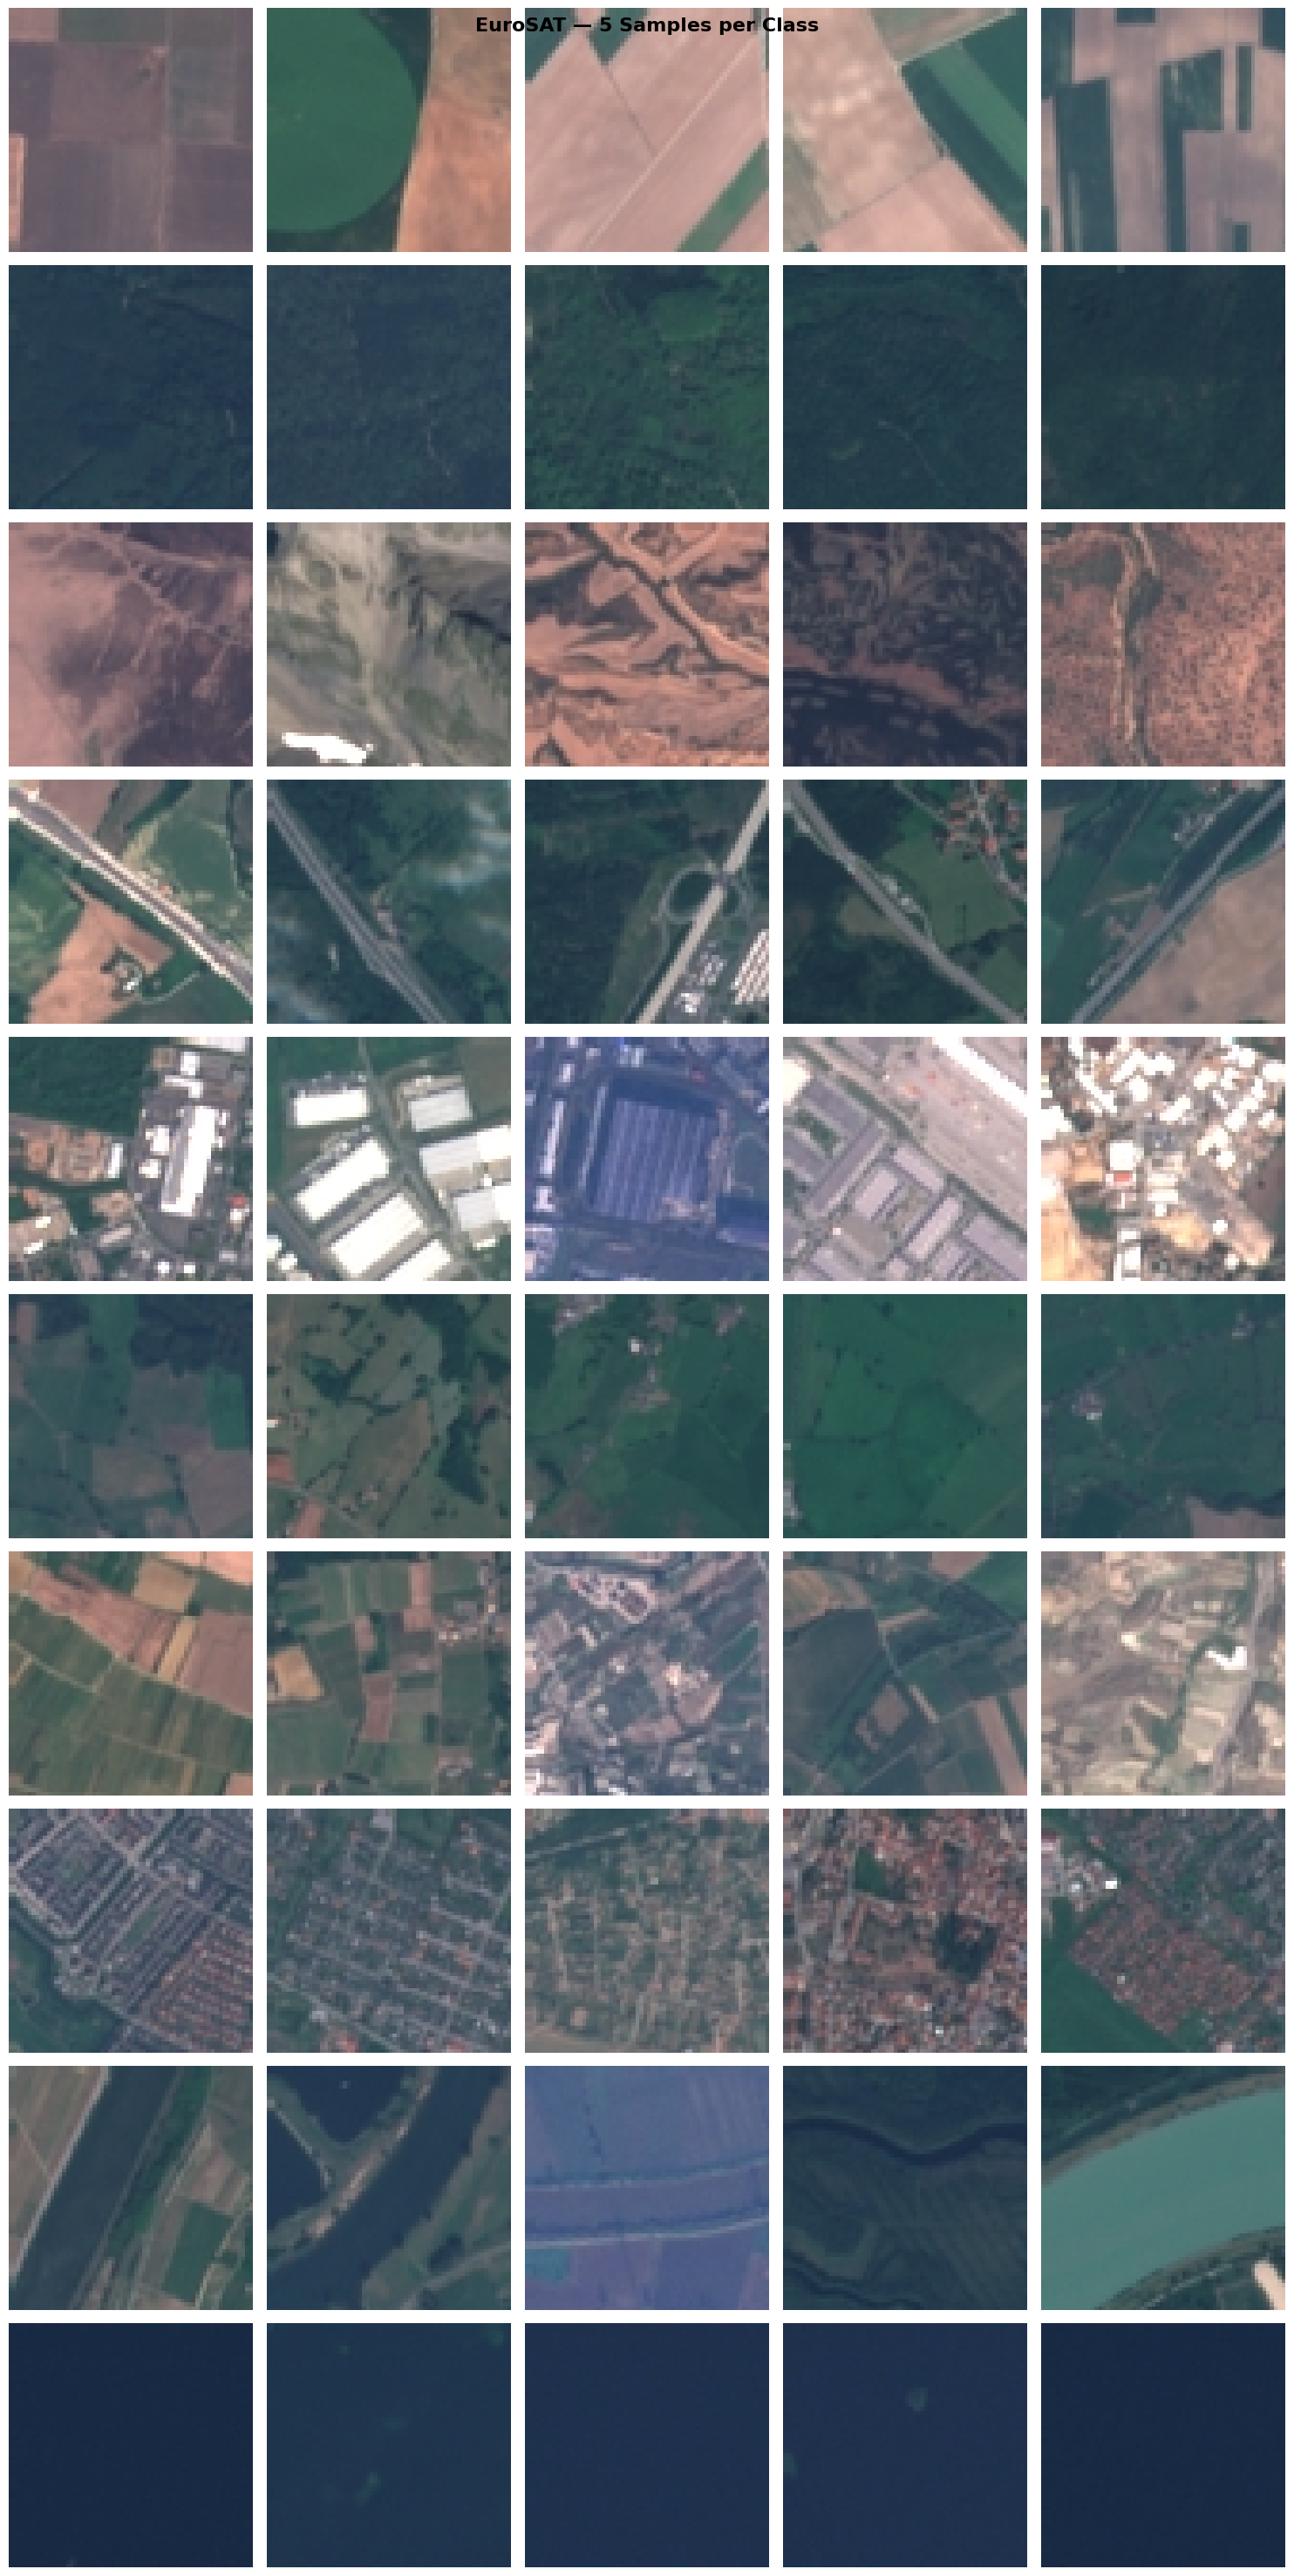

Saved samples_per_class.png


In [3]:
# ── Visualize 5 samples per class ──────────────────────────────────────────
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(15, len(CLASSES) * 3))
fig.suptitle('EuroSAT — 5 Samples per Class', fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASSES):
    cls_dir = EURO_DIR / cls
    imgs = list(cls_dir.glob('*.jpg'))[:5]
    for col, img_path in enumerate(imgs):
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=10, rotation=0, labelpad=60)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'samples_per_class.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved samples_per_class.png')

C:\Users\harsh\AppData\Local\Temp\ipykernel_23060\2328109655.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_counts.keys(), rotation=45, ha='right')


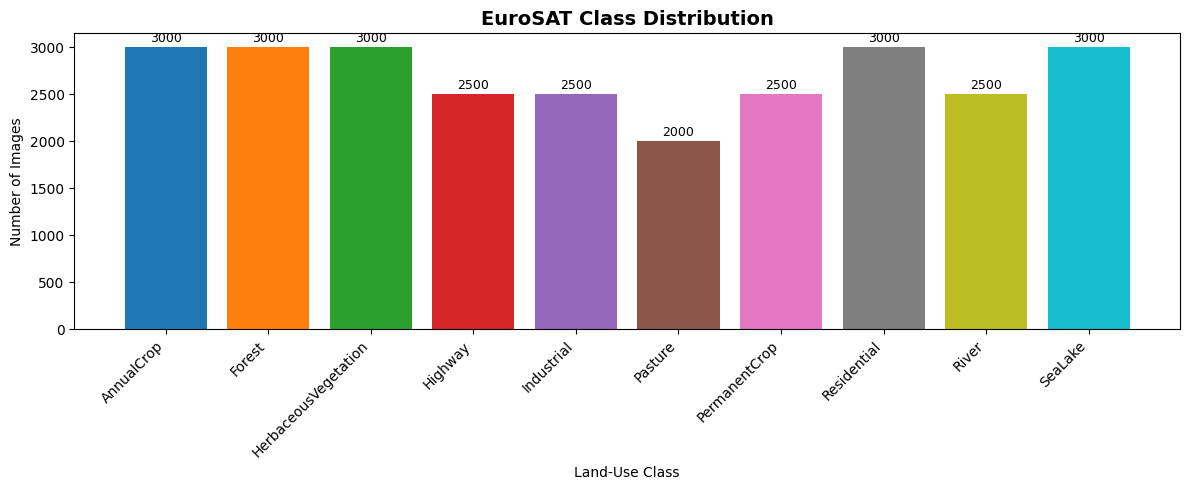

Total images: 27000


In [4]:
# ── Class distribution ──────────────────────────────────────────────────────
class_counts = {cls: len(list((EURO_DIR / cls).glob('*.jpg'))) for cls in CLASSES}

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=plt.cm.tab10(range(len(CLASSES))))
ax.set_title('EuroSAT Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Land-Use Class')
ax.set_ylabel('Number of Images')
ax.set_xticklabels(class_counts.keys(), rotation=45, ha='right')
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'class_distribution.png', dpi=100)
plt.show()
print('Total images:', sum(class_counts.values()))

In [5]:
# ── Spatial Block Train / Val / Test Split ─────────────────────────────────
# EuroSAT images are named <Class>_<index>.jpg
# We simulate spatial blocks by sorting file indices and splitting sequentially.
# Block A (indices 0–69%) = train, B (70–84%) = val, C (85–100%) = test
# This prevents spatial leakage (geographically close patches stay in same split).

random.seed(42)
np.random.seed(42)

SPLIT_DIR = DATA_DIR / 'split'
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

split_stats = {'train': 0, 'val': 0, 'test': 0}

for cls in CLASSES:
    files = sorted((EURO_DIR / cls).glob('*.jpg'),
                   key=lambda p: int(''.join(filter(str.isdigit, p.stem)) or '0'))
    n = len(files)
    t1, t2 = int(0.70 * n), int(0.85 * n)
    splits = {'train': files[:t1], 'val': files[t1:t2], 'test': files[t2:]}
    for split_name, split_files in splits.items():
        for src in split_files:
            dst = SPLIT_DIR / split_name / cls / src.name
            if not dst.exists():
                shutil.copy2(src, dst)
        split_stats[split_name] += len(split_files)

print('Spatial block split complete:')
for k, v in split_stats.items():
    print(f'  {k:6s}: {v} images')

Spatial block split complete:
  train : 18900 images
  val   : 4050 images
  test  : 4050 images


In [6]:
# ── DataLoaders ─────────────────────────────────────────────────────────────
IMG_SIZE = 64
BATCH    = 64

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(SPLIT_DIR / 'train', transform=train_tf)
val_ds   = datasets.ImageFolder(SPLIT_DIR / 'val',   transform=val_tf)
test_ds  = datasets.ImageFolder(SPLIT_DIR / 'test',  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print('Classes:', train_ds.classes)

# Save class index for later notebooks
import json
with open(BASE_DIR / 'src' / 'class_names.json', 'w') as f:
    json.dump(train_ds.classes, f)
print('class_names.json saved.')

Train: 18900 | Val: 4050 | Test: 4050
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
class_names.json saved.


In [7]:
# ── Spatial leakage baseline: random split accuracy reference ───────────────
# We document the split method here. The comparison experiment runs in notebook 03.
print('Spatial block split strategy documented.')
print('- Train block  : indices 0–69% per class (geographically sequential)')
print('- Val block    : indices 70–84% per class')
print('- Test block   : indices 85–100% per class')
print('This avoids geographically adjacent patches leaking between train/test.')
print('Comparison with random split accuracy will be reported in notebook 03.')

Spatial block split strategy documented.
- Train block  : indices 0–69% per class (geographically sequential)
- Val block    : indices 70–84% per class
- Test block   : indices 85–100% per class
This avoids geographically adjacent patches leaking between train/test.
Comparison with random split accuracy will be reported in notebook 03.
